In [3]:
%pip install pandas matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd

# Load CSV
df = pd.read_csv("japanese_racehorse_goats.csv")

#Previewing the data
df.head()

,HorseName,Era,YearsActive,TotalStarts,Wins,WinRatePercent,Grade1Wins,TotalEarningsJPY_Millions,PrimaryDistance_meters,Surface
0,Deep Impact,2004-2006,3,14,12,85.7,7,1450,2400,Turf
1,Orfevre,2010-2013,4,21,12,57.1,6,1320,2400,Turf
2,Symboli Rudolf,1984-1986,3,16,13,81.3,7,680,2400,Turf
3,Kitasan Black,2015-2017,3,20,12,60.0,7,1870,3200,Turf
4,Tokai Teio,1990-1993,4,12,9,75.0,4,620,2400,Turf


In [5]:
df.describe()


,YearsActive,TotalStarts,Wins,WinRatePercent,Grade1Wins,TotalEarningsJPY_Millions
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,3.100000,16.200000,9.800000,64.030000,4.550000,1073.500000
std,0.718185,5.890224,2.706717,14.137263,1.959457,562.693475
min,2.000000,4.000000,4.000000,38.500000,2.000000,310.000000
25%,3.000000,11.750000,8.000000,56.900000,3.000000,647.500000
50%,3.000000,16.000000,10.000000,60.000000,4.000000,935.000000
75%,4.000000,21.000000,12.000000,72.700000,7.000000,1352.500000
max,4.000000,26.000000,14.000000,100.000000,7.000000,2400.000000


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

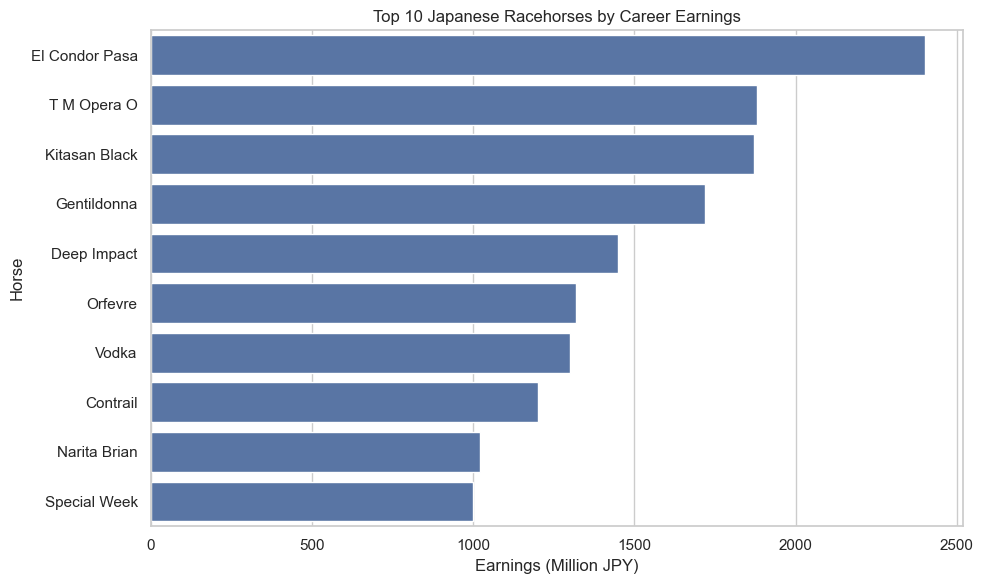

In [7]:
#Finding the top 10 horses by their earnings in JPY
top_earnings = df.sort_values(
    by="TotalEarningsJPY_Millions",
    ascending=False
).head(10)
#Sizing the bars and naming the axis'
plt.figure(figsize=(10,6))
sns.barplot(
    data=top_earnings,
    x="TotalEarningsJPY_Millions",
    y="HorseName"
)
plt.title("Top 10 Japanese Racehorses by Career Earnings")
plt.xlabel("Earnings (Million JPY)")
plt.ylabel("Horse")
plt.tight_layout()
plt.show()

Very quickly and simply shows who has earned the most money. From here we seet that even in the top 10 the differences are quite big between the top and the bottom earners

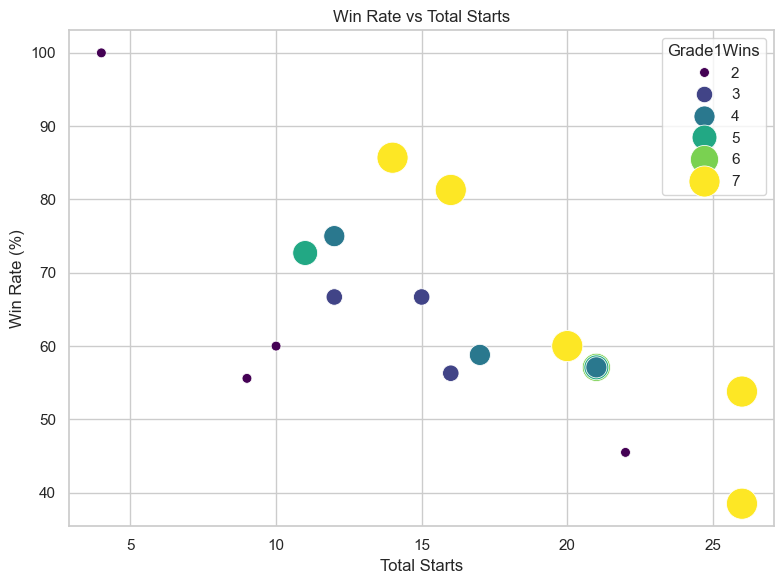

In [8]:
#Finding out if the amoung of races has some big impact on the overall winrate
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="TotalStarts",
    y="WinRatePercent",
    size="Grade1Wins",
    sizes=(50, 500),
    hue="Grade1Wins",
    palette="viridis"
)

plt.title("Win Rate vs Total Starts")
plt.xlabel("Total Starts")
plt.ylabel("Win Rate (%)")
plt.tight_layout()
plt.show()

Here we see that there's a clear trend where the more that a horse races the lower the overall career winrate will be.

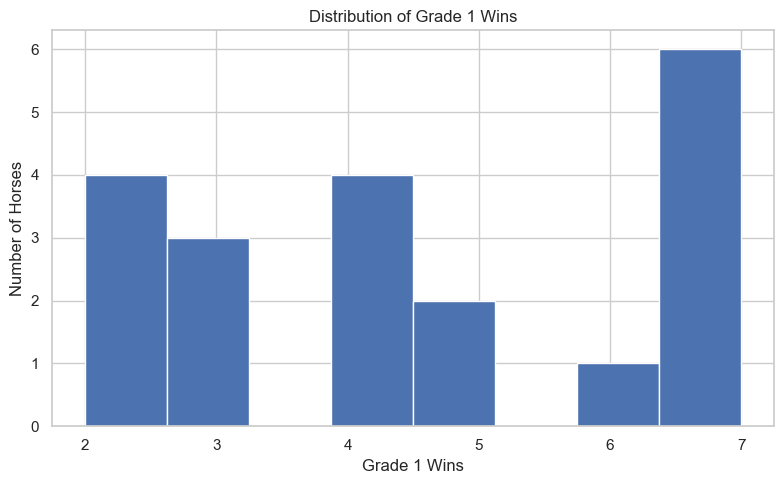

In [ ]:
#Showing how many horses have how many G1 wins.
plt.figure(figsize=(8,5))
plt.hist(df["Grade1Wins"], bins=8)
plt.title("Distribution of Grade 1 Wins")
plt.xlabel("Grade 1 Wins")
plt.ylabel("Number of Horses")
plt.tight_layout()
plt.show()

Seeing that even among the top Japanese racehorses of all time the chance to have above 5 G1 wins is quite low. Showing that those with 6 or 7 G1 wins during their careers were on a complete level of their own.

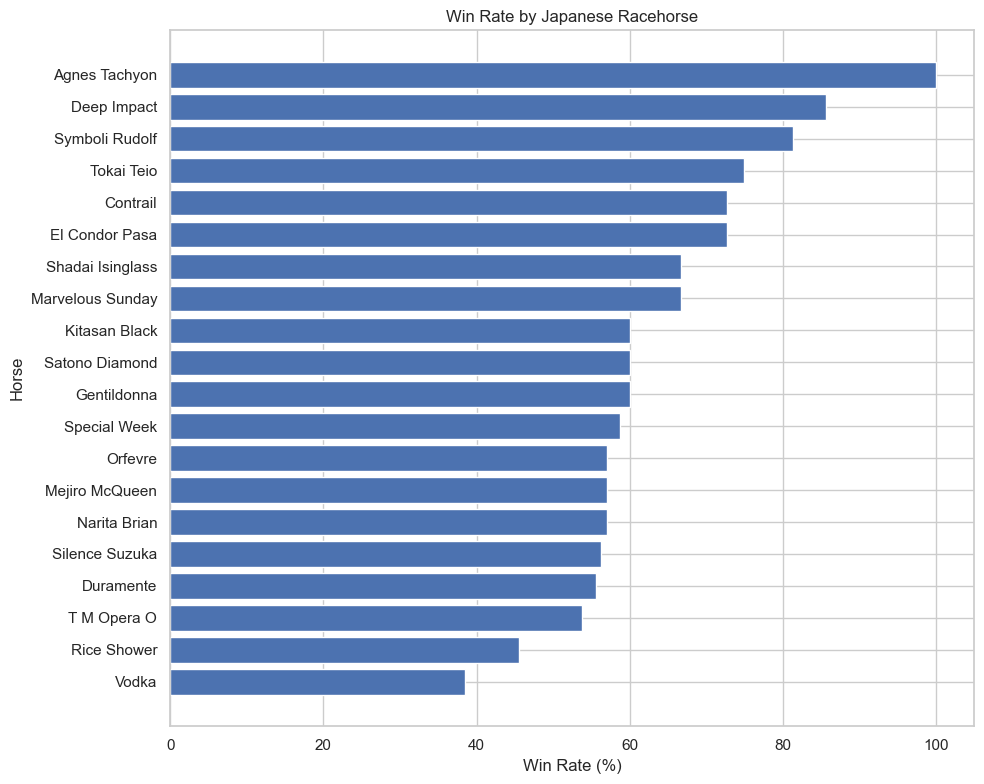

In [ ]:
# Sortin horses by their win rate
df_sorted = df.sort_values("WinRatePercent", ascending=True)

plt.figure(figsize=(10,8))
plt.barh(
    df_sorted["HorseName"],
    df_sorted["WinRatePercent"]
)

plt.title("Win Rate by Japanese Racehorse")
plt.xlabel("Win Rate (%)")
plt.ylabel("Horse")
plt.tight_layout()
plt.show()

A simple chart to see the horses Winrates over all of their races. From here it's interesting to see that even horses that are considered extraordinary have can negative win rates (below 50%) over their entire career. This shows how tumultous and hard to predict racehorsing can be.

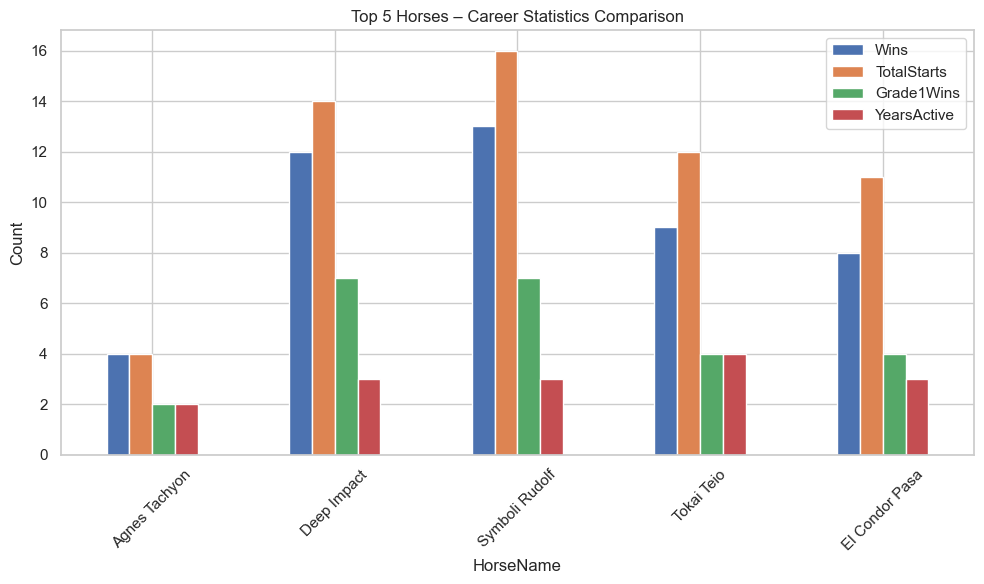

In [ ]:
#Picking the top5 horses by winrate and showing all their statistics to compare them
top5 = df.sort_values("WinRatePercent", ascending=False).head(5)

metrics = ["Wins", "TotalStarts", "Grade1Wins", "YearsActive"]
top5_metrics = top5.set_index("Horse Name")[metrics]

top5_metrics.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Top 5 Horses – Career Statistics Comparison")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Since these are some of the best of all time I'll do a more detailed

Agnes Tachyion: Although a very short compared to the others, her 100% winrate is quite impressive espeially with half of the races being G1. Knowing the story behind the horse, her career was short due to an injury.

Deep Impact and Symboli Rudolf: Deep Impacts career was one that almost rivalled that of Symboli Rudolfs, the undisputed best Japanese racehorse to this day. What's most impressive to me is just the amount of races they partook in during their 3 year careers. This is a sign of them having very few if any injuries during their careers which is quite rare and impressive. 

Tokai Teio and El Condor Pasa: Compared to the last two we can see there's a huge difference in their win ratio of their careers, beeing a markable 10-20% lower. With also a lower ratio of G1 race participations eventhough their careers lasted for longer. Seeing this I can confidently conclude that Deep Impact and Symboli Rudolf are in a league of their own when it comes to Japanese horseracing.

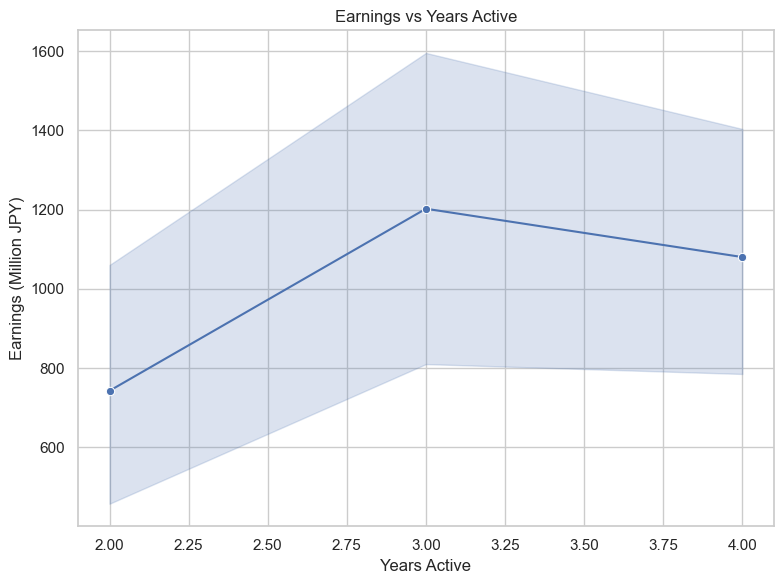

In [ ]:
#Looking at the what's the impact of time as a racer and the horses earnings
plt.figure(figsize=(8,6))
sns.lineplot(
    data=df,
    x="YearsActive",
    y="TotalEarningsJPY_Millions",
    marker="o"
)

plt.title("Earnings vs Years Active")
plt.xlabel("Years Active")
plt.ylabel("Earnings (Million JPY)")
plt.tight_layout()
plt.show()


Here we see that the intensive careers of race horses that last around 3 years have the most earnings. The fact that the earnings go down after this shows that the most successful racehorses careers were all around 3 years long.